# SMACNP Training — Combined ERA5 + PeakWeather Context

Trains a Sparse Multi-head Attention Convolutional Neural Process (SMACNP) for
daily mean temperature downscaling over Switzerland, using a **combined context**
of ERA5 reanalysis grid cells and PeakWeather station observations.

## Context and target

- **Context (what the model sees each day)**:
  ERA5 reanalysis grid (~1769 cells at ~25 km resolution) **plus** the 60 % of
  PeakWeather stations assigned to the training split (~103 stations).
  A source flag (7th feature: 0 = ERA5, 1 = PW station) lets the model learn
  to weight high-fidelity station measurements more heavily than coarse
  reanalysis estimates.
- **Validation target**: the 20 % of PeakWeather stations assigned to the
  validation split (~34 stations), using their raw PW observations as ground
  truth (no MeteoSwiss data needed).
- **Test target** (evaluated in the prediction notebook): the remaining 20 %
  of PeakWeather stations (~35 stations), never seen during training.

## Cross-validation

5-fold cross-validation over time. Each fold holds out a contiguous fifth of
the common ERA5–PW date range. The model is re-initialised
and retrained from scratch for each fold.

## Normalisation

Both ERA5 and PW temperatures are normalised using the same ERA5 statistics
(mean and std computed over the ERA5 domain), so all context temperatures are
on a consistent scale. The saved `metadata.json` contains these statistics for
use in the prediction notebook.


In [19]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [20]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Training configuration - modify these parameters as needed
TEMPERATURE_TYPE = 'mean'
PW_FIRST_DATE = '2017-01-01'
PW_LAST_DATE  = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99

PARAMS = params.Params(
    VARIABLE='tmax',
    TEMPERATURE_TYPE=TEMPERATURE_TYPE,
    MODEL_TYPE='smacnp',
    CONTEXT_TYPE='combined',
    PW_TRAIN_FRAC=0.6,
    PW_VAL_FRAC=0.2,
    STATION_SPLIT_SEED=42,
    N_EPOCHS=30,
    N_FOLDS=5,
    TRIAL_NAME='test-combined-era5-pw-mean',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=True,
    # SMACNP architecture
    R_DIM=128,
    W_DIM=128,
    V_DIM=128,
    N_HEADS=4,
    SMACNP_HIDDEN=128,
    USE_PE=True,
    PE_DIM=32,
)

print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, TEMPERATURE_TYPE='mean', SEASONAL_FEATURES=True, SEASONAL_FEATURES_IN_MLP=True, USE_ELEVATION=True, USE_MTPI=True, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=30, BATCH_SIZE=8, LR=0.0005, PATIENCE=20, N_FOLDS=5, SEED=42, TRIAL_NAME='test-ms-pw-stations-mean', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, ERA5_MEAN_TEMP_GLOB=None, METEO_SWISS_MEAN_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None, MODEL_TYPE='smacnp', R_DIM=128, W_DIM=128, V_DIM=128, N_HEADS=4, SMACNP_HIDDEN=128, USE_PE=True, PE_DIM=32, PW_TRAIN_FRAC=0.6, PW_VAL_FRAC=0.2, STATION_SPLIT_SEED=42, CONTEXT_TYPE='peakweather')


In [22]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_smacnp

In [23]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

# Note: loading datasets on Renkulab directly from Polybox was no working well.
# Things do work if we first sync the files over to local storage and then load them
# locally.
cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 2.19 seconds.
29 directories parsed, 0 files copied

Dataset sync complete.


In [ ]:
if TEMPERATURE_TYPE == 'max':
    _era5_glob = PARAMS.ERA5_MAX_TEMP_GLOB
    _era5_var  = 't2m_max'
else:
    _era5_glob = PARAMS.ERA5_MEAN_TEMP_GLOB
    _era5_var  = 't2m'

era5_tensor, era5_metadata, _, time_coords_era5 = ds.load_era5_data(
    _era5_glob,
    var_name=_era5_var,
    year_start=None,            
    geopotential_glob=PARAMS.ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    include_seasonal_embeddings=PARAMS.SEASONAL_FEATURES,
    device=device,
)
era5_dates_pd = pd.DatetimeIndex(pd.to_datetime(time_coords_era5).date.astype(str))
x_era5, y_era5 = ds.build_smacnp_context(era5_tensor)
print(f"ERA5 context: x_era5={x_era5.shape}, y_era5={y_era5.shape}")
print(f"ERA5 date range: {era5_dates_pd[0]} → {era5_dates_pd[-1]}")
# era5_tensor: (T_era5, 6, 29, 61)
# x_era5: (T_era5, 1769, 6)
# y_era5: (T_era5, 1769, 1)

In [ ]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)

In [24]:
# Load PeakWeather stations (all valid stations, before split)
daily_tmean_pw, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    aggregation_method='mean',
)
pw_dates_pd = pd.DatetimeIndex(daily_tmean_pw.index.date.astype(str))

# Seasonal features from PW time axis
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if PARAMS.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}")
else:
    seasonal_features = None


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Seasonal features shape: torch.Size([2921, 2])


In [25]:
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=PARAMS.PW_TRAIN_FRAC,
    val_frac=PARAMS.PW_VAL_FRAC,
    seed=PARAMS.STATION_SPLIT_SEED,
)

Station split: 103 train / 34 val / 35 test


In [ ]:
# Both ERA5 and PW must cover the same dates for combined context.
# Take the intersection: typically 2017-01-01 → 2023-12-31
common_dates = pw_dates_pd.intersection(era5_dates_pd)
print(f"PW dates:      {len(pw_dates_pd)} ({pw_dates_pd[0]} → {pw_dates_pd[-1]})")
print(f"ERA5 dates:    {len(era5_dates_pd)} ({era5_dates_pd[0]} → {era5_dates_pd[-1]})")
print(f"Common dates:  {len(common_dates)} ({common_dates[0]} → {common_dates[-1]})")

# Index arrays to slice each source to the common date range
era5_idx = np.array([era5_dates_pd.get_loc(d) for d in common_dates])
pw_idx   = np.array([pw_dates_pd.get_loc(d)   for d in common_dates])

# Slice ERA5 context to common dates
x_era5_aligned = x_era5[era5_idx]                           # (T_common, 1769, 6)
y_era5_aligned = y_era5[era5_idx]                           # (T_common, 1769, 1)

# Slice seasonal features to common dates (they follow PW time axis)
seasonal_features_aligned = seasonal_features[pw_idx]       # (T_common, 2)
T_common = len(common_dates)

In [ ]:
x_pw_train, y_pw_train = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean_pw,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=era5_metadata,              # ERA5 stats — same scale as ERA5 context
    seasonal_features=seasonal_features_aligned,
    dates_pd=common_dates,               # common dates only
    device=device,
)
y_pw_train = y_pw_train.unsqueeze(-1)
y_pw_train = torch.nan_to_num(y_pw_train, nan=0.0)
print(f"PW train context: x={x_pw_train.shape}, y={y_pw_train.shape}")
# x_pw_train: (T_common, 103, 6)
# y_pw_train: (T_common, 103, 1)

In [ ]:
x_context, y_context = ds.build_combined_context(
    x_era5_aligned, y_era5_aligned,
    x_pw_train, y_pw_train,
)
print(f"Combined context: x={x_context.shape}, y={y_context.shape}")
# x_context: (T_common, 1769 + 103, 7)   ← 7th feature is source flag (0=ERA5, 1=PW)
# y_context: (T_common, 1769 + 103, 1)


In [ ]:
params.set_seed(PARAMS.SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

# Save era5_metadata — prediction notebook will reload this for consistent normalization
PARAMS.save_json(OUTPUT_DIR / 'params.json')
ds.save_metadata_json(era5_metadata, OUTPUT_DIR / 'metadata.json')

# Val targets: PW val stations, aligned to common dates
x_target, y_target = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean_pw,           # PW observations directly (no MeteoSwiss)
    station_ids=val_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=era5_metadata,              # same normalization as context
    seasonal_features=seasonal_features_aligned,
    dates_pd=common_dates,               # common dates only
    device=device,
)
print(f"x_target: {x_target.shape}   # (T_common, {len(val_stations)}, 6)")
print(f"y_target: {y_target.shape}   # (T_common, {len(val_stations)})")

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    params.set_seed(PARAMS.SEED + fold)

    # KEY CHANGE: pass both input_dim (target, 6) and context_input_dim (combined, 7)
    model, loss_fn, get_value_fn = model_factory.build_smacnp(
        PARAMS,
        input_dim=x_target.shape[-1],           # 6 — target has no source flag
        context_input_dim=x_context.shape[-1],  # 7 — combined context has source flag
    )
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    train_smacnp(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        x_context=x_context,   # (T_common, 1872, 7)
        y_context=y_context,   # (T_common, 1872, 1)
        x_target=x_target,     # (T_common, 34, 6)
        y_target=y_target,     # (T_common, 34)
        output_dir=OUTPUT_DIR,
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=fold_stats_file,
        device=device,
    )
    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)


x_target: torch.Size([2921, 34, 6])  # (T, N_val, 6)
y_target: torch.Size([2921, 34])  # (T, N_val)

Starting fold 1/5...

Built SMACNP with 308,995 trainable parameters
Fold 1/5 | Epoch 0 | train NLL nan | test NLL 0.091 | med MAE 0.126 | elapsed 3s | est. remaining 92s
Fold 1/5 | Epoch 1 | train NLL 0.079 | test NLL 0.076 | med MAE 0.102 | elapsed 6s | est. remaining 88s
Fold 1/5 | Epoch 2 | train NLL 0.052 | test NLL 0.053 | med MAE 0.069 | elapsed 10s | est. remaining 85s
Fold 1/5 | Epoch 3 | train NLL 0.053 | test NLL 0.056 | med MAE 0.077 | elapsed 13s | est. remaining 83s
Fold 1/5 | Epoch 4 | train NLL 0.044 | test NLL 0.046 | med MAE 0.061 | elapsed 16s | est. remaining 80s
Fold 1/5 | Epoch 5 | train NLL 0.043 | test NLL 0.047 | med MAE 0.063 | elapsed 19s | est. remaining 77s
Fold 1/5 | Epoch 6 | train NLL 0.039 | test NLL 0.053 | med MAE 0.070 | elapsed 23s | est. remaining 74s
Fold 1/5 | Epoch 7 | train NLL 0.042 | test NLL 0.042 | med MAE 0.055 | elapsed 26s | est. remainin

In [33]:
OUTPUT_DIR
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

In [34]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/test-ms-pw-stations-mean/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,NaN,NaN,NaN,0,NaN,NaN
1,0,NaN,NaN,NaN,1,NaN,NaN
2,0,NaN,NaN,NaN,2,NaN,NaN
3,0,NaN,NaN,NaN,3,NaN,NaN
4,0,NaN,NaN,NaN,4,NaN,NaN
...,...,...,...,...,...,...,...
194,4,0.048313,0.997660,0.996491,25,0.036695,0.035231
195,4,0.050091,0.997576,0.996418,26,0.036289,0.036930
196,4,0.061885,0.997484,0.996556,27,0.035457,0.040927
197,4,0.055393,0.997546,0.996331,28,0.038952,0.041215


  Saved plot: trained_models/test-ms-pw-stations-mean/trainingstats_fold0


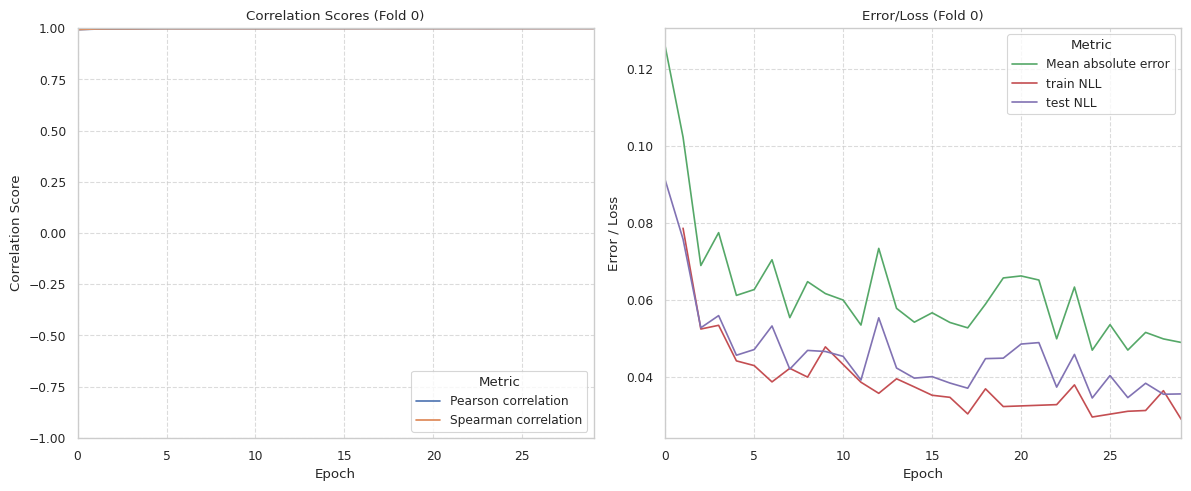

  Saved plot: trained_models/test-ms-pw-stations-mean/trainingstats_fold1


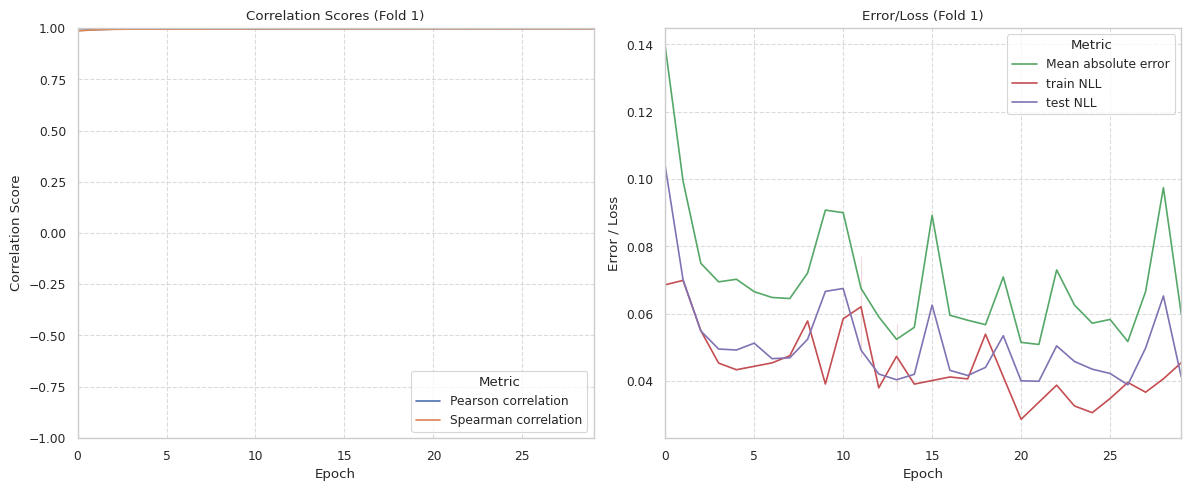

  Saved plot: trained_models/test-ms-pw-stations-mean/trainingstats_fold2


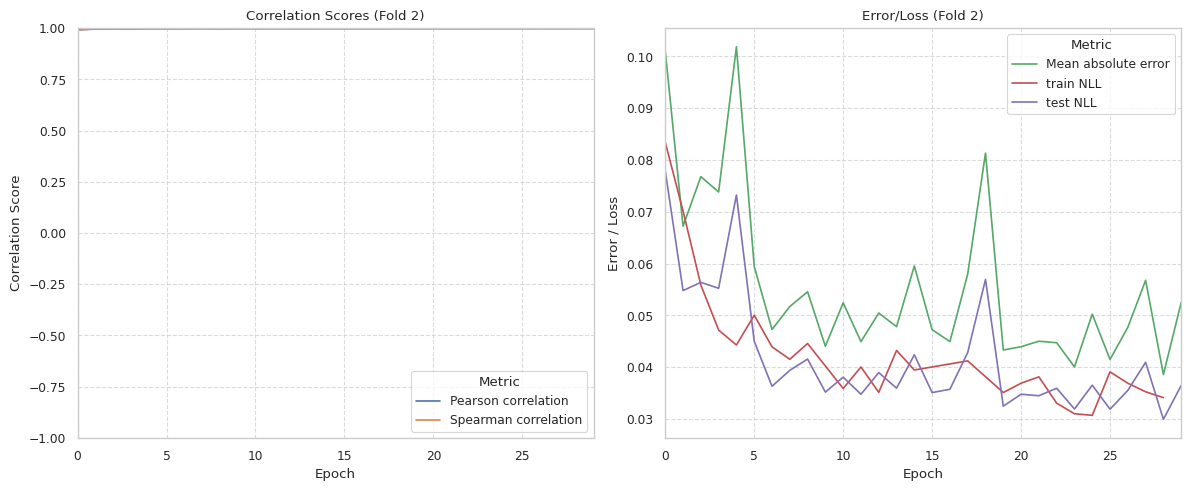

  Saved plot: trained_models/test-ms-pw-stations-mean/trainingstats_fold3


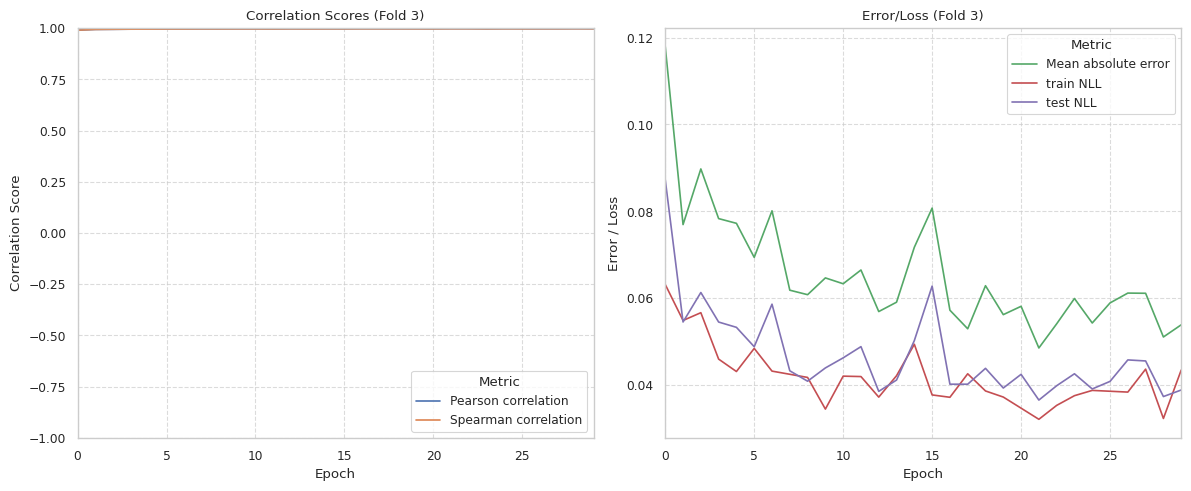

  Saved plot: trained_models/test-ms-pw-stations-mean/trainingstats_fold4


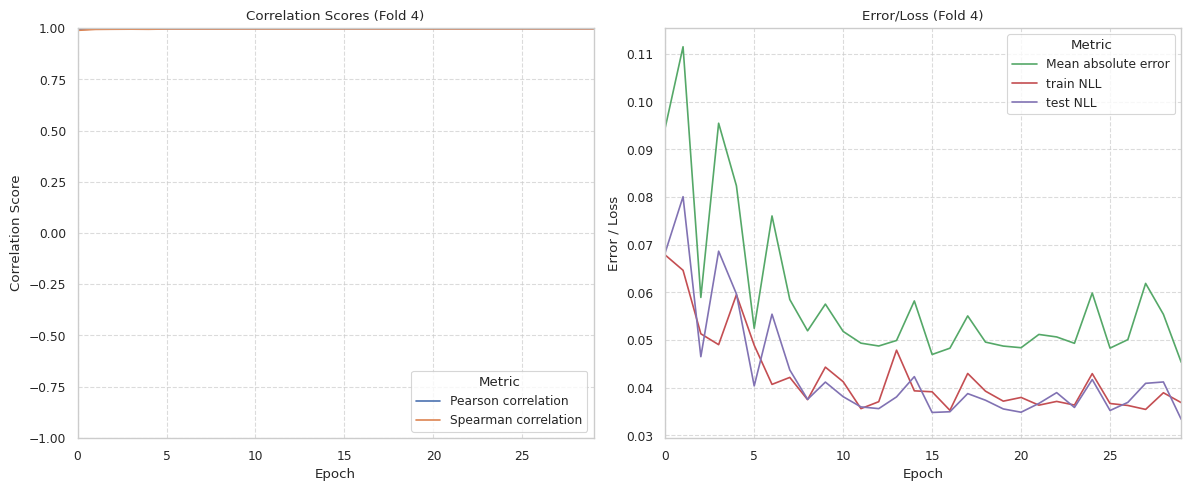

  Saved plot: trained_models/test-ms-pw-stations-mean/trainingstats_all


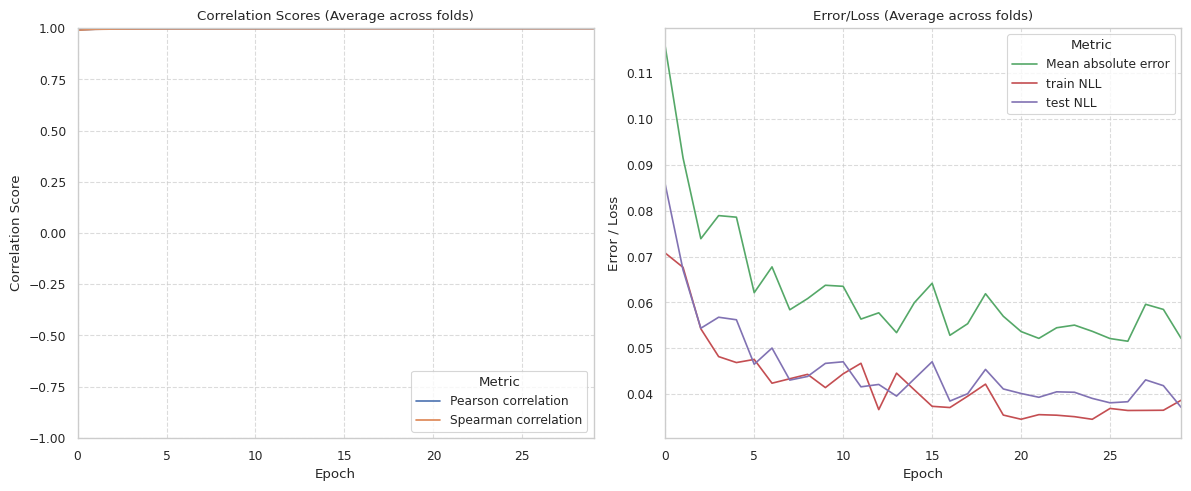

In [35]:
save_path_prefix = str(OUTPUT_DIR / 'trainingstats')
vis.plot_training_curves(stats, save_path=save_path_prefix)
plt.show()